# 1. Import & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 2. Daten einlesen

In [6]:
file_path = "../data/Number_of_fires_by_month.csv"
# CSV mit Semikolon-Trenner einlesen
df = pd.read_csv(file_path, sep=";", header=1, encoding="ISO-8859-1")

# 3. Datenbereinigung

In [7]:
# Spaltennamen aufräumen
df.columns = df.columns.str.strip()

# "Data Qualifier"-Spalte entfernen (falls vorhanden)
df = df.loc[:, ~df.columns.str.contains('Data Qualifier', case=False)]


# Alle 'Unspecified'-Einträge in 'Month' löschen
df = df[df["Month"].notna()]
df = df[~df['Month'].str.contains("Unspecified", case=False, na=False)]


# Alle leeren Werte durch NaN ersetzen
df = df.replace(["", " ",], np.nan)


# "Wide" → "Long" Format
df_long = df.melt(
    id_vars=["Jurisdiction", "Month"],  # diese Spalten bleiben fix
    var_name="Year",                    # Name der neuen "Jahr"-Spalte
    value_name="Number_fires"                  # Name für die Werte (z. B. Anzahl Brände)
)

#df_long["Month"] = pd.to_datetime(df_long["Month"], format="%B").dt.month
#Datei speichern
#output_path = "../data/cleaned_wlags_Number_of_fires_by_month.csv"
#df_long.to_csv(output_path, index=False)

# 4. Explorative Visualisierung

Basisinfo

In [11]:
print(df_long.info())
print(df_long.describe())

# Fehlende Werte je Spalte
print(df_long.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4624 entries, 0 to 4623
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Jurisdiction  4624 non-null   object 
 1   Month         4624 non-null   object 
 2   Year          4624 non-null   object 
 3   Number_fires  3234 non-null   float64
dtypes: float64(1), object(3)
memory usage: 144.6+ KB
None
       Number_fires
count   3234.000000
mean      71.323748
std      131.497892
min        0.000000
25%        4.000000
50%       22.000000
75%       83.750000
max     2118.000000
Jurisdiction       0
Month              0
Year               0
Number_fires    1390
dtype: int64


Zeitreihen Visualisierung

C:\Users\Anwender\AppData\Local\Temp\ipykernel_24644\857115171.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ts_total["Date"] = pd.to_datetime(ts_total["Year"].astype(str) + "-" + ts_total["Month"].astype(str))


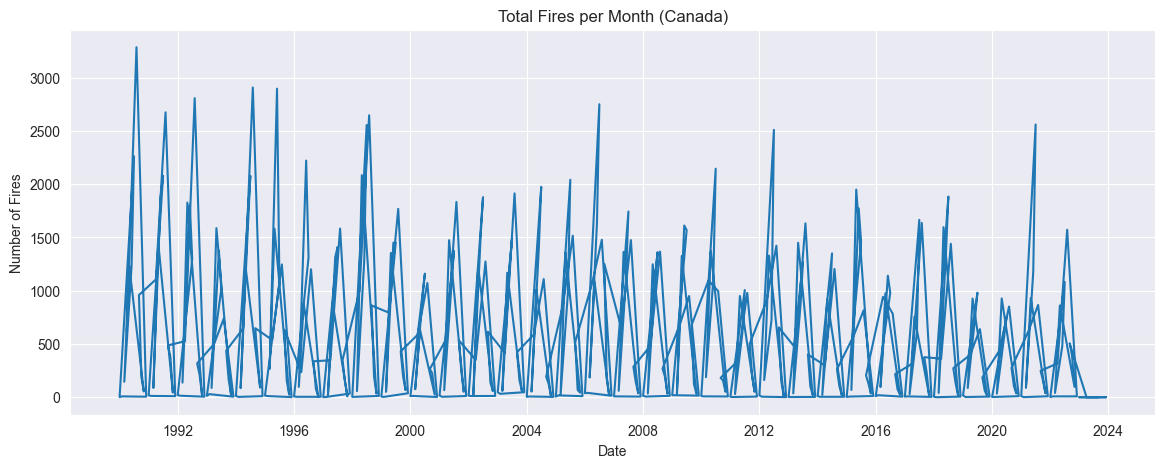

In [12]:
# Gesamtzeitreihe
ts_total = (
    df_long.groupby(["Year", "Month"])["Number_fires"]
    .sum()
    .reset_index()
)
ts_total["Date"] = pd.to_datetime(ts_total["Year"].astype(str) + "-" + ts_total["Month"].astype(str))

plt.figure(figsize=(14,5))
plt.plot(ts_total["Date"], ts_total["Number_fires"])
plt.title("Total Fires per Month (Canada)")
plt.xlabel("Date")
plt.ylabel("Number of Fires")
plt.show()


Zeitreihen Jurisdiction

C:\Users\Anwender\AppData\Local\Temp\ipykernel_24644\2875180838.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(subset["Year"].astype(str) + "-" + subset["Month"].astype(str)),
C:\Users\Anwender\AppData\Local\Temp\ipykernel_24644\2875180838.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(subset["Year"].astype(str) + "-" + subset["Month"].astype(str)),
C:\Users\Anwender\AppData\Local\Temp\ipykernel_24644\2875180838.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(subset["Year"].astype(str) + "-" + subset["Month"].astype

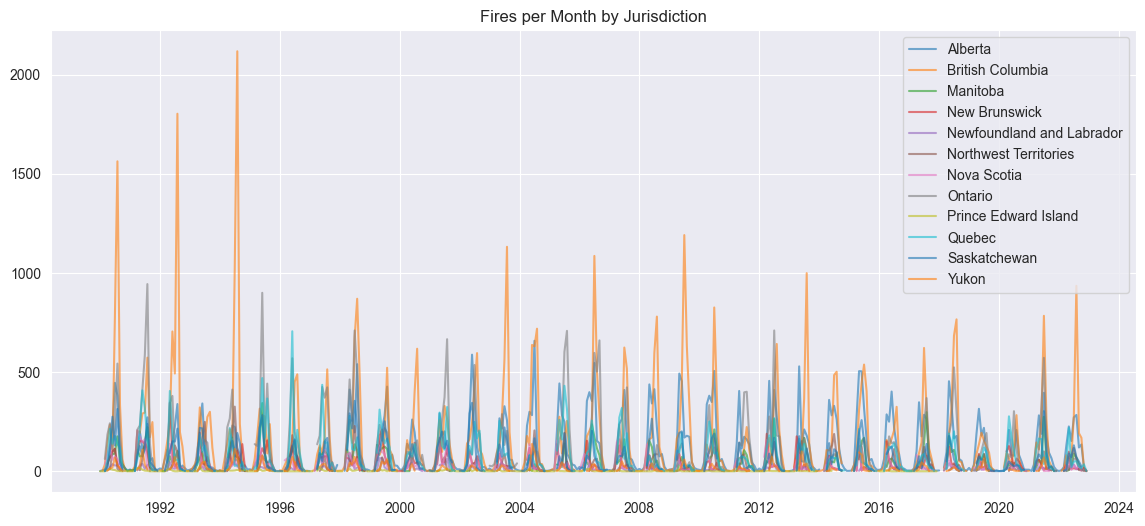

In [13]:
plt.figure(figsize=(14,6))
for j in df_long["Jurisdiction"].unique():
    subset = df_long[df_long["Jurisdiction"] == j]
    plt.plot(
        pd.to_datetime(subset["Year"].astype(str) + "-" + subset["Month"].astype(str)),
        subset["Number_fires"],
        label=j,
        alpha=0.6
    )
plt.legend()
plt.title("Fires per Month by Jurisdiction")
plt.show()


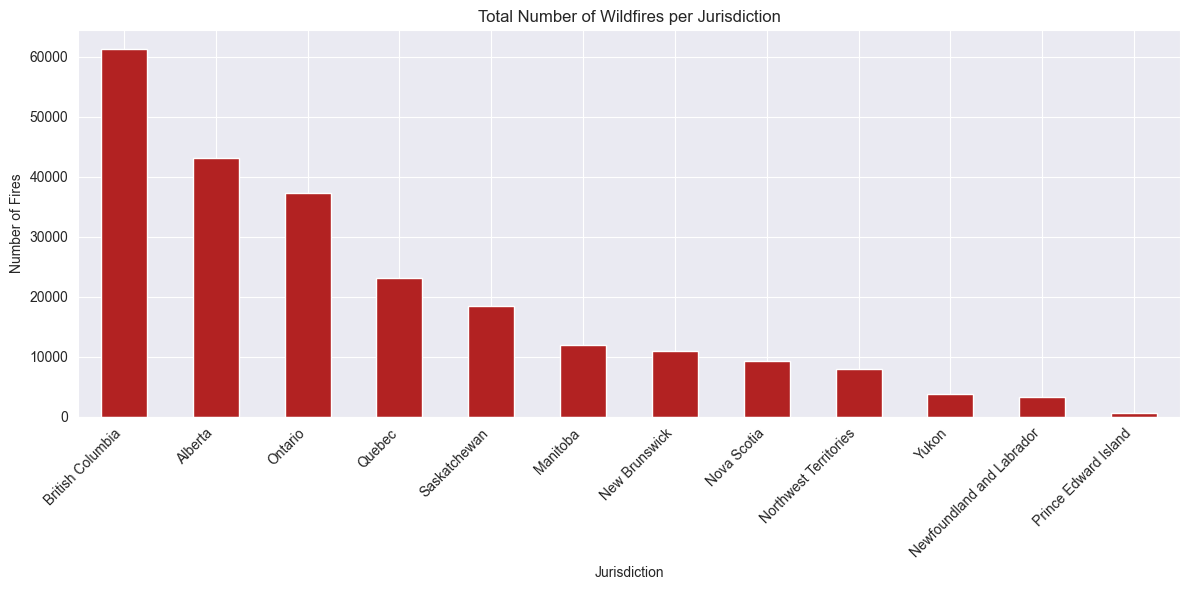

In [14]:
# Summe der Waldbrände pro Region berechnen
fires_per_region = (
    df_long.groupby("Jurisdiction")["Number_fires"]
           .sum()
           .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(12,6))
fires_per_region.plot(kind="bar", color="firebrick")

plt.title("Total Number of Wildfires per Jurisdiction")
plt.ylabel("Number of Fires")
plt.xlabel("Jurisdiction")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Saisonale Muster

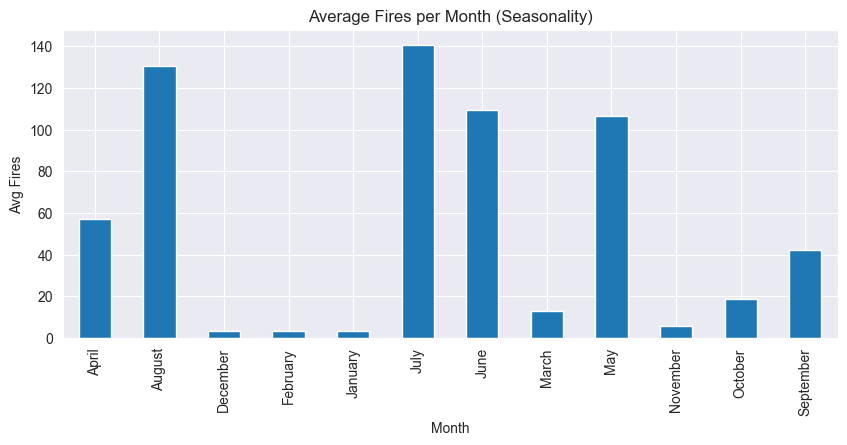

In [15]:
monthly_avg = df_long.groupby("Month")["Number_fires"].mean()

plt.figure(figsize=(10,4))
monthly_avg.plot(kind="bar")
plt.title("Average Fires per Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Avg Fires")
plt.show()


<Figure size 1200x500 with 0 Axes>

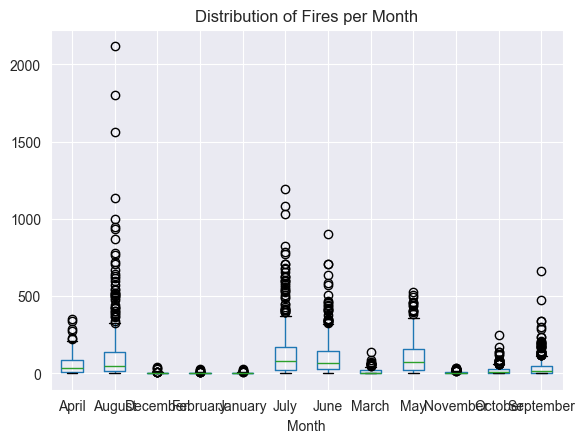

In [16]:
plt.figure(figsize=(12,5))
df_long.boxplot(column="Number_fires", by="Month")
plt.title("Distribution of Fires per Month")
plt.suptitle("")
plt.show()

Heatmap Jahr x Monat

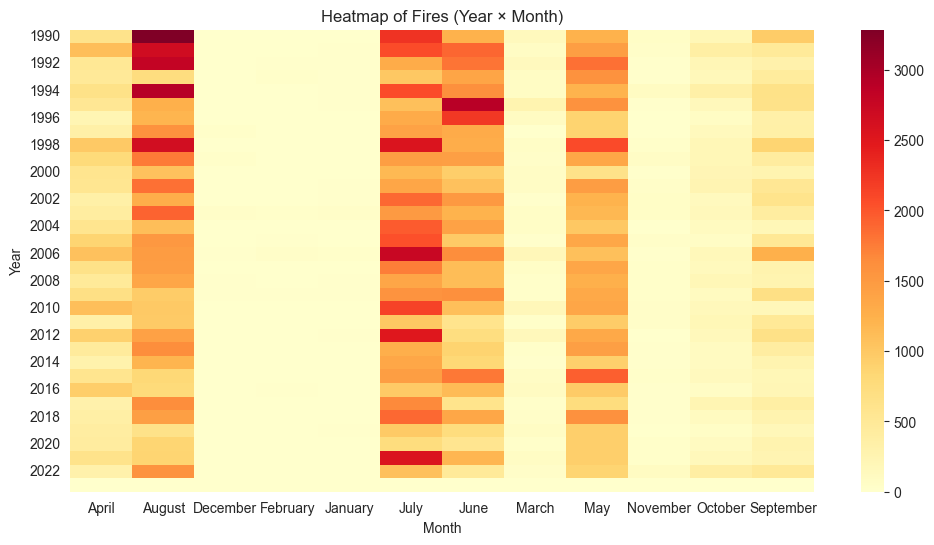

In [17]:
pivot = df_long.pivot_table(
    index="Year",
    columns="Month",
    values="Number_fires",
    aggfunc="sum"
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Heatmap of Fires (Year × Month)")
plt.show()

Autokorrelation

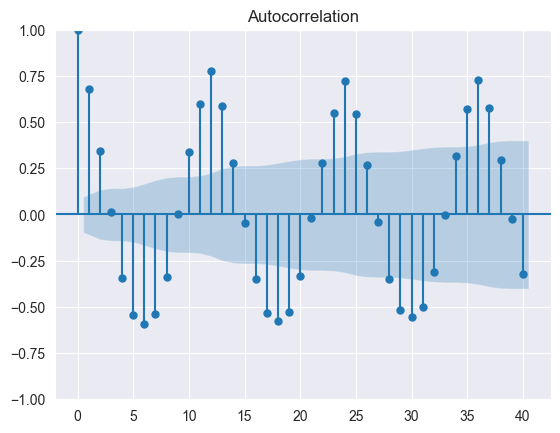

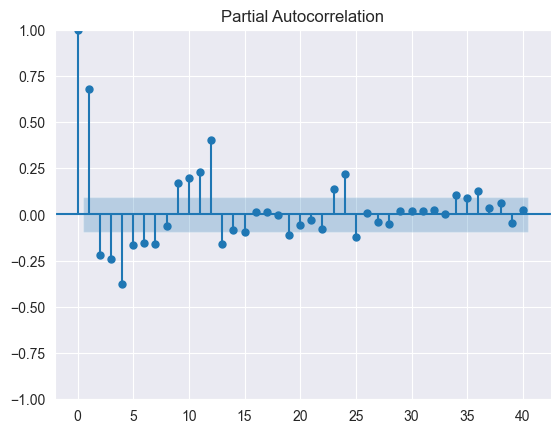

In [18]:
# Kanada-gesamt Zeitreihe
ts_total_sorted = ts_total.sort_values("Date")

plot_acf(ts_total_sorted["Number_fires"].dropna(), lags=40)
plt.show()

plot_pacf(ts_total_sorted["Number_fires"].dropna(), lags=40)
plt.show()

Ausreißer identifizieren

<Figure size 1200x600 with 0 Axes>

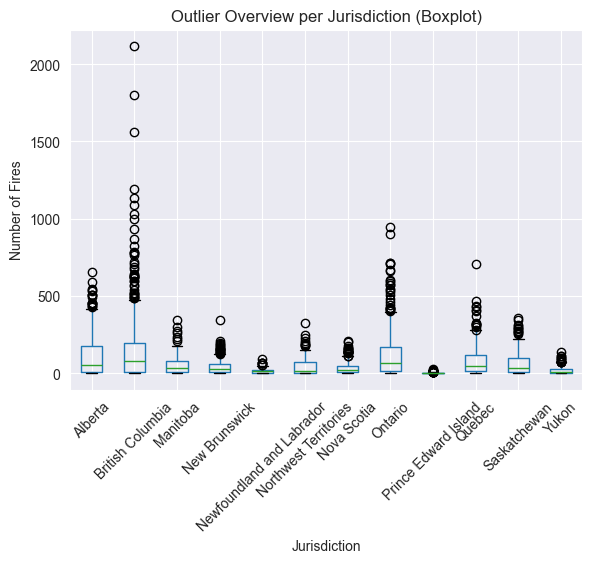

In [19]:
plt.figure(figsize=(12,6))
df_long.boxplot(column="Number_fires", by="Jurisdiction", rot=45)
plt.title("Outlier Overview per Jurisdiction (Boxplot)")
plt.suptitle("")
plt.xlabel("Jurisdiction")
plt.ylabel("Number of Fires")
plt.show()

# 5. Feature Engineering

In [20]:
# Datentypen anpassen
df_long["Year"] = df_long["Year"].astype(int)

# Anzahl (Number_fires) als ganze Zahl
df_long["Number_fires"] = pd.to_numeric(df_long["Number_fires"], errors="coerce").astype("Int64")

# Jurisdiction als Kategorie, Month als 1–12 umwandeln
df_long["Jurisdiction"] = df_long["Jurisdiction"].astype("category")
df_long["Month"] = pd.to_datetime(df_long["Month"], format="%B").dt.month

# Funktion zur Zuweisung der Jahreszeit (Season)
def get_season(month):
    # Definitionen: Frühling (März-Mai), Sommer (Juni-August),
    # Herbst (September-November) und Winter (Dezember-Februar)
    if month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Fall"
    elif month in [12, 1, 2]:
        return "Winter"
    return np.nan

# Anwenden der Funktion auf die numerische Monatsspalte
df_long["Season"] = df_long["Month"].apply(get_season)

# Lag hinzufügen, vorherige Werte merken
df_long = df_long.sort_values(["Jurisdiction", "Year", "Month"])

df_long["Lag_1"] = df_long.groupby("Jurisdiction")["Number_fires"].shift(1)
df_long["Lag_2"] = df_long.groupby("Jurisdiction")["Number_fires"].shift(2)
df_long["Lag_3"] = df_long.groupby("Jurisdiction")["Number_fires"].shift(3)

# Rolling / Window Features (gleitende Statistiken)
# Berechnung erfolgt pro Jurisdiction, um regionale Unterschiede korrekt abzubilden

# Rolling Mean: Glättet kurzfristige Schwankungen
df_long["RollMean_3"]  = df_long.groupby("Jurisdiction")["Number_fires"].transform(lambda x: x.rolling(window=3,  min_periods=1).mean())
df_long["RollMean_6"]  = df_long.groupby("Jurisdiction")["Number_fires"].transform(lambda x: x.rolling(window=6,  min_periods=1).mean())
df_long["RollMean_12"] = df_long.groupby("Jurisdiction")["Number_fires"].transform(lambda x: x.rolling(window=12, min_periods=1).mean())

# Rolling Standard Deviation: Erfasst lokale Volatilität
df_long["RollStd_3"]  = df_long.groupby("Jurisdiction")["Number_fires"].transform(lambda x: x.rolling(window=3,  min_periods=1).std())
df_long["RollStd_6"]  = df_long.groupby("Jurisdiction")["Number_fires"].transform(lambda x: x.rolling(window=6,  min_periods=1).std())
df_long["RollStd_12"] = df_long.groupby("Jurisdiction")["Number_fires"].transform(lambda x: x.rolling(window=12, min_periods=1).std())

# Rolling Sum: Gesamtanzahl der letzten Monate
df_long["RollSum_3"]  = df_long.groupby("Jurisdiction")["Number_fires"].transform(lambda x: x.rolling(window=3,  min_periods=1).sum())
df_long["RollSum_6"]  = df_long.groupby("Jurisdiction")["Number_fires"].transform(lambda x: x.rolling(window=6,  min_periods=1).sum())
df_long["RollSum_12"] = df_long.groupby("Jurisdiction")["Number_fires"].transform(lambda x: x.rolling(window=12, min_periods=1).sum())

# Trigonometrisches Encoding für Monat (1–12)
df_long["Month_sin"] = np.sin(2 * np.pi * df_long["Month"] / 12)
df_long["Month_cos"] = np.cos(2 * np.pi * df_long["Month"] / 12)

# One Hot Encoding
df_long["Jurisdiction_raw"] = df_long["Jurisdiction"].astype(str)
df_long = pd.get_dummies(df_long, columns=["Jurisdiction"], prefix="REG", drop_first=False)
reg_cols = [col for col in df_long.columns if col.startswith("REG")]
df_long[reg_cols] = df_long[reg_cols].astype(int)

# Kontrolle
df_long[["Month", "Month_sin", "Month_cos"]].head(12)
df_long[["Number_fires", "Lag_1", "RollMean_3", "RollStd_6"]].head(15)
print(df_long.head(20))
print(df_long.dtypes)

     Month  Year  Number_fires  Season  Lag_1  Lag_2  Lag_3  RollMean_3  \
0        1  1990             1  Winter   <NA>   <NA>   <NA>    1.000000   
1        2  1990             5  Winter      1   <NA>   <NA>    3.000000   
2        3  1990             8  Spring      5      1   <NA>    4.666667   
3        4  1990            26  Spring      8      5      1   13.000000   
4        5  1990           114  Spring     26      8      5   49.333333   
5        6  1990           214  Summer    114     26      8  118.000000   
6        7  1990           446  Summer    214    114     26  258.000000   
7        8  1990           381  Summer    446    214    114  347.000000   
8        9  1990           117    Fall    381    446    214  314.666667   
9       10  1990            34    Fall    117    381    446  177.333333   
10      11  1990            16    Fall     34    117    381   55.666667   
11      12  1990             4  Winter     16     34    117   18.000000   
136      1  1991         

C:\Users\Anwender\AppData\Local\Temp\ipykernel_24644\934846386.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_long["Lag_1"] = df_long.groupby("Jurisdiction")["Number_fires"].shift(1)
C:\Users\Anwender\AppData\Local\Temp\ipykernel_24644\934846386.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_long["Lag_2"] = df_long.groupby("Jurisdiction")["Number_fires"].shift(2)
C:\Users\Anwender\AppData\Local\Temp\ipykernel_24644\934846386.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavi

In [21]:
#Datei speichern
output_path = "../data/cleaned_Number_of_fires_by_month.csv"
df_long.to_csv(output_path, index=False)

# 6. Merge Wetterdaten

In [9]:
# Spalte time löschen und alle Wettertabellen zu einem Datenset mergen
province_files = {
    "Alberta": "../data/cleaned_Alberta_monthly_mean.csv",
    "British Columbia": "../data/cleaned_British_Columbia_monthly_mean.csv",
    "Manitoba": "../data/cleaned_Manitoba_monthly_mean.csv",
    "New Brunswick": "../data/cleaned_New_Brunswick_monthly_mean.csv",
    "Newfoundland and Labrador": "../data/cleaned_Newfoundland_and_Labrador_monthly_mean.csv",
    "Northwest Territories": "../data/cleaned_Northwest_Territories_monthly_mean.csv",
    "Nova Scotia": "../data/cleaned_Nova_Scotia_monthly_mean.csv",
    "Ontario": "../data/cleaned_Ontario_monthly_mean.csv",
    "Prince Edward Island": "../data/cleaned_Prince_Edward_Island_monthly_mean.csv",
    "Quebec": "../data/cleaned_Quebec_monthly_mean.csv",
    "Saskatchewan": "../data/cleaned_Saskatchewan_monthly_mean.csv",
    "Yukon": "../data/cleaned_Yukon_monthly_mean.csv"
}

weather_dfs = []

for province, path in province_files.items():
    df = pd.read_csv(path)

    if "time" in df.columns:
        df = df.drop(columns=["time"])

    df["Year"] = df["Year"].astype(int)
    df["Month"] = df["Month"].astype(int)
    df["Jurisdiction_raw"] = province

    weather_dfs.append(df)

# Alle Wetterdaten in eine Tabelle
df_weather_all = pd.concat(weather_dfs, ignore_index=True)
# Speichern des DataFrames als CSV-Datei
df_weather_all.to_csv("../data/weather_all.csv", index=False)

print(df_weather_all.shape)
print(df_weather_all.columns)

(4764, 13)
Index(['temperature_2m_mean (°C)', 'temperature_2m_max (°C)',
       'relative_humidity_2m_mean (%)', 'relative_humidity_2m_min (%)',
       'precipitation_sum (mm)', 'precipitation_hours (h)',
       'wind_speed_10m_mean (km/h)', 'wind_speed_10m_max (km/h)',
       'wind_direction_10m_dominant (°)', 'et0_fao_evapotranspiration (mm)',
       'Year', 'Month', 'Jurisdiction_raw'],
      dtype='object')


In [10]:
# Spalten löschen aufgrund der Korrel. Analyse (Finale Feature Definition)
cols_to_drop = [
    "precipitation_sum (mm)",
    "precipitation_hours (h)",
    "wind_speed_10m_mean (km/h)",
    "wind_speed_10m_max (km/h)",
    "wind_direction_10m_dominant (°)"
]

df_weather = df_weather_all.drop(
    columns=[c for c in cols_to_drop if c in df_weather_all.columns]
)
print(df_weather.columns)
print(df_weather.dtypes)


Index(['temperature_2m_mean (°C)', 'temperature_2m_max (°C)',
       'relative_humidity_2m_mean (%)', 'relative_humidity_2m_min (%)',
       'et0_fao_evapotranspiration (mm)', 'Year', 'Month', 'Jurisdiction_raw'],
      dtype='object')
temperature_2m_mean (°C)           float64
temperature_2m_max (°C)            float64
relative_humidity_2m_mean (%)      float64
relative_humidity_2m_min (%)       float64
et0_fao_evapotranspiration (mm)    float64
Year                                 int64
Month                                int64
Jurisdiction_raw                    object
dtype: object


# 6. Merge Wetterdaten & Anzahl Brände

In [12]:
# Number of fires laden
df_fires = pd.read_csv(
    "../data/cleaned_Number_of_fires_by_month.csv"
)

#Finaler Merge
df_merged = pd.merge(
    df_fires,
    df_weather_all,
    on=["Jurisdiction_raw", "Year", "Month"],
    how="inner"
)

print(df_merged.shape)
print(df_merged.isna().sum())
print(df_merged.head())

# Speichern des DataFrames als CSV-Datei
df_merged.to_csv("../data/final_data.csv", index=False)

(4498, 41)
Month                                 0
Year                                  0
Number_fires                       1264
Season                                0
Lag_1                              1266
Lag_2                              1271
Lag_3                              1279
RollMean_3                          608
RollMean_6                          166
RollMean_12                          76
RollStd_3                          1214
RollStd_6                           379
RollStd_12                          104
RollSum_3                           608
RollSum_6                           166
RollSum_12                           76
Month_sin                             0
Month_cos                             0
Jurisdiction_raw                      0
REG_Alberta                           0
REG_British Columbia                  0
REG_Manitoba                          0
REG_New Brunswick                     0
REG_Newfoundland and Labrador         0
REG_Northwest Territories    

# 7. Feature Engineering Wetterdaten + Vorbereitung für den Split

In [13]:
df_merged = df_merged.sort_values(["Jurisdiction_raw", "Year", "Month"])

weather_features = [
    "temperature_2m_mean (°C)",
    "relative_humidity_2m_mean (%)",
    "et0_fao_evapotranspiration (mm)"
]

for col in weather_features:
    df_merged[f"{col}_lag1"] = (
        df_merged.groupby("Jurisdiction_raw")[col].shift(1)
    )

# Speichern des DataFrames als CSV-Datei
df_merged.to_csv("../data/final_data.csv", index=False)


In [3]:
# Number of fires als Zielvariabel setzen und NaNs in Number of fires löschen
target = "Number_fires"
df_model = df_merged[df_merged[target].notna()].copy()
df_model.to_csv("../data/final_data.csv", index=False)

NameError: name 'df_merged' is not defined

In [4]:
df_model = pd.read_csv(
    "../data/final_data.csv"
)

target = "Number_fires"

X = df_model.drop(columns=[target])
y = df_model[target]


# 8. Train/ Test Split

In [6]:
# Training: ca. 60% der Zeit (1990–2012), Validation: ca. 20 % (2013–2017), Test: ca. 20 % (2018–2023)
# Features / Target
X = df_model.drop(columns=["Number_fires"])
y = df_model["Number_fires"]

# Train
X_train = X[X["Year"] <= 2012]
y_train = y[X["Year"] <= 2012]

# Validation
X_val = X[(X["Year"] > 2012) & (X["Year"] <= 2017)]
y_val = y[(X["Year"] > 2012) & (X["Year"] <= 2017)]

# Test
X_test = X[X["Year"] > 2017]
y_test = y[X["Year"] > 2017]

print(X_train["Year"].max(), X_test["Year"].min())

2012 2018


In [7]:
#Numerische Features identifizieren
num_cols = X_train.select_dtypes(include=["number"]).columns
X_train[num_cols].isna().sum().sort_values(ascending=False).head(10)

Lag_3                                   573
Lag_2                                   427
Lag_1                                   263
RollStd_3                               194
RollStd_6                                67
RollStd_12                               13
temperature_2m_mean (°C)_lag1             3
et0_fao_evapotranspiration (mm)_lag1      3
relative_humidity_2m_mean (%)_lag1        3
RollMean_12                               0
dtype: int64

In [8]:
#Median Imputation
imputer = SimpleImputer(strategy="median")

# NUR auf Trainingsdaten fitten
X_train[num_cols] = imputer.fit_transform(X_train[num_cols])

# Gleiche Transformation auf Testdaten anwenden
X_test[num_cols] = imputer.transform(X_test[num_cols])

print("Train NaNs:", X_train.isna().sum().max())
print("Test NaNs:", X_test.isna().sum().max())

y.describe()

Train NaNs: 0
Test NaNs: 0


C:\Users\Anwender\AppData\Local\Temp\ipykernel_11516\3983533689.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
C:\Users\Anwender\AppData\Local\Temp\ipykernel_11516\3983533689.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[num_cols] = imputer.transform(X_test[num_cols])


,Jurisdiction_raw,Year,Month
0,Alberta,1990,1
1,Alberta,1990,2
2,Alberta,1990,3
3,Alberta,1990,4
4,Alberta,1990,5


In [12]:
# Season und Jurisdiction raw entfernen
X_train = X_train.drop(columns=["Season", "Jurisdiction_raw"])
X_val   = X_val.drop(columns=["Season", "Jurisdiction_raw"])
X_test  = X_test.drop(columns=["Season", "Jurisdiction_raw"])

# 9. Baseline trainieren - Random Forest

In [13]:
from sklearn.ensemble import RandomForestRegressor
#Random-Forest-Baseline definieren
rf_baseline = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

In [14]:
#Modell trainieren
rf_baseline.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
#Vorhersage trainieren
y_pred_train = rf_baseline.predict(X_train)
y_pred_val   = rf_baseline.predict(X_val)
y_pred_test  = rf_baseline.predict(X_test)

# 10. Baseline Modell evaluieren - Random Forest

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} → MAE: {mae:.2f}, RMSE: {rmse:.2f}")

evaluate(y_train, y_pred_train, "Train")
evaluate(y_val,   y_pred_val,   "Validation")
evaluate(y_test,  y_pred_test,  "Test")


Train → MAE: 5.94, RMSE: 16.20
Validation → MAE: 12.87, RMSE: 28.50
Test → MAE: 13.23, RMSE: 31.16


# 9a Baseline trainieren - XGBoost

In [17]:
from xgboost import XGBRegressor
# Baseline definieren
xgb_baseline = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [18]:
# Baseline Modell trainieren
xgb_baseline.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [19]:
#Vorhersagen erzeugen
y_pred_train_xgb = xgb_baseline.predict(X_train)
y_pred_val_xgb   = xgb_baseline.predict(X_val)
y_pred_test_xgb  = xgb_baseline.predict(X_test)

# 10a Baseline evaluieren - XG Boost

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} → MAE: {mae:.2f}, RMSE: {rmse:.2f}")

evaluate(y_train, y_pred_train_xgb, "Train")
evaluate(y_val,   y_pred_val_xgb,   "Validation")
evaluate(y_test,  y_pred_test_xgb,  "Test")


Train → MAE: 1.90, RMSE: 2.60
Validation → MAE: 14.86, RMSE: 28.59
Test → MAE: 10.53, RMSE: 24.41


# 6. Modellauswahl

# 7. Training & Evaluation

# 8. Interpretation & Ergebnisse

# 9. Export der Modelle/Plots